### Regional Analysis

In [25]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from scipy.stats import binned_statistic_2d

In [26]:
plt.rcParams.update({
    'font.size': 14,          
    'axes.labelsize': 16,     
    'axes.titlesize': 16,     
    'xtick.labelsize': 13,    
    'ytick.labelsize': 13,    
    'legend.fontsize': 12,    
    'figure.titlesize': 18,   
    'font.family': 'sans-serif',
    'text.usetex': False       
})

In [27]:
# Paths and constants
DATA_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/data"
OUTPUT_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/outputs"

In [28]:
# Loading data
os.chdir(DATA_DIR)
files = {
    'AVISO': 'ADT-0.25_interpolated.parquet',
    'GLOBCURRENT': 'GLOBCURRENT_interpolated.parquet',
    'OSCAR': 'OSCAR-tot_interpolated.parquet',
    'NEUROST': 'NEUROST_interpolated.parquet',   
    'GLORYS': 'GLORYS_interpolated.parquet',
    'TOPAZ': 'TOPAZ4b_interpolated.parquet',
}

MODEL_COLORS = {
    'AVISO': 'orange',        
    'GLOBCURRENT': 'green',  
    'OSCAR': 'magenta',      
    'NEUROST': 'cyan',      
    'GLORYS': 'blue',     
    'TOPAZ': 'red'       
}

all_data = []
for name, path in files.items():
    df = pd.read_parquet(path)
    df = df.rename(columns={'vn': 'v_obs', 've': 'u_obs'})
    df['model_name'] = name
    
    # Calculate scalar speeds and errors
    df['speed_obs'] = np.sqrt(df['u_obs']**2 + df['v_obs']**2)
    df['speed_model'] = np.sqrt(df['u_model']**2 + df['v_model']**2)
    df['err_speed'] = df['speed_model'] - df['speed_obs']
    df['err_u'] = df['u_model'] - df['u_obs']
    df['err_v'] = df['v_model'] - df['v_obs']
    df['rmse_speed']  = np.abs(df['err_speed'])  
    
    all_data.append(df)

master_df = pd.concat(all_data, ignore_index=True)
master_df['model_name'] = master_df['model_name'].astype('category')
master_df['id_sector'] = master_df['id_sector'].astype('category')

In [29]:
master_df

,id_drifter,time,latitude,longitude,lon360,u_obs,v_obs,id_sector,u_model,v_model,model_name,speed_obs,speed_model,err_speed,err_u,err_v,rmse_speed
0,104126,2011-11-15 00:00:00+00:00,54.14250,-161.02625,198.97375,-0.083290,-0.065552,Out,-0.370619,-0.153856,AVISO,0.105992,0.401285,0.295294,-0.287329,-0.088304,0.295294
1,104126,2011-11-16 00:00:00+00:00,54.08925,-161.20250,198.79750,-0.166035,-0.067110,Out,-0.379337,-0.167701,AVISO,0.179085,0.414753,0.235669,-0.213303,-0.100590,0.235669
2,104126,2011-11-17 00:00:00+00:00,54.04275,-161.43050,198.56950,-0.190586,-0.043945,Out,-0.383183,-0.166080,AVISO,0.195587,0.417627,0.222040,-0.192597,-0.122136,0.222040
3,104126,2011-11-18 00:00:00+00:00,54.01025,-161.70675,198.29325,-0.240829,-0.064287,Out,-0.392395,-0.157174,AVISO,0.249261,0.422702,0.173441,-0.151566,-0.092887,0.173441
4,104126,2011-11-19 00:00:00+00:00,53.98300,-162.05775,197.94225,-0.253266,0.017257,Out,-0.385387,-0.168414,AVISO,0.253853,0.420579,0.166725,-0.132121,-0.185670,0.166725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661711,300234068341750,2021-12-26 00:00:00+00:00,80.98975,21.94050,21.94050,-0.035997,0.072783,S3,0.029824,0.085307,TOPAZ,0.081198,0.090370,0.009172,0.065821,0.012524,0.009172
661712,300234068341750,2021-12-27 00:00:00+00:00,80.99875,21.69225,21.69225,-0.024076,-0.052091,S3,0.001844,0.026397,TOPAZ,0.057385,0.026461,-0.030924,0.025920,0.078488,0.030924
661713,300234068341750,2021-12-28 00:00:00+00:00,80.95575,21.80275,21.80275,0.030357,-0.030002,S3,0.001320,-0.016408,TOPAZ,0.042681,0.016461,-0.026220,-0.029037,0.013594,0.026220
661714,300234068341750,2021-12-29 00:00:00+00:00,80.95350,21.70450,21.70450,-0.054364,0.013616,S3,0.015738,0.047358,TOPAZ,0.056043,0.049905,-0.006139,0.070102,0.033742,0.006139


In [30]:
# Regional Metrics Calculation
def get_regional_metrics(x):
    """Computes RMSE, Bias, and Correlation for each sector group."""
    stats = {}
    pairs = {
        'Speed': ('speed_model', 'speed_obs', 'err_speed'),
        'U': ('u_model', 'u_obs', 'err_u'),
        'V': ('v_model', 'v_obs', 'err_v')
    }
    
    for label, (mod, obs, err) in pairs.items():
        stats[f'RMSE_{label}'] = np.sqrt(np.mean(x[err]**2))
        stats[f'Bias_{label}'] = np.mean(x[err])
        stats[f'Corr_{label}'] = x[obs].corr(x[mod])
    return pd.Series(stats)

# Grouping by Model and Sector
regional_stats = (
    master_df.groupby(['model_name', 'id_sector'], observed=True)
    .apply(get_regional_metrics, include_groups=False)
    .reset_index()
)

In [31]:
def plot_regional_heatmap(df, metrics, titles, output_path):
    """Heatmap of metrics: rows=sectors, columns=models."""
    models = list(MODEL_COLORS.keys())
    sectors = sorted(df['id_sector'].unique())
    sectors.remove('Out')

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 8))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric, title in zip(axes, metrics, titles):
        # Build matrix: sectors x models
        matrix = pd.DataFrame(index=sectors, columns=models, dtype=float)
        for model in models:
            subset = df[df['model_name'] == model].set_index('id_sector')
            matrix[model] = subset.reindex(sectors)[metric]

        is_bias = 'Bias' in metric
        is_corr = 'Corr' in metric

        if is_bias:
            limit = np.nanmax(np.abs(matrix.values))
            norm = TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit)
            cmap = 'RdBu_r'
        elif is_corr:
            norm = TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)
            cmap = 'RdYlGn'
        else:
            norm = None
            cmap = 'YlOrRd'

        im = ax.imshow(matrix.values.astype(float), cmap=cmap, norm=norm, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=14)
        ax.set_yticks(range(len(sectors)))
        ax.set_yticklabels(sectors, fontsize=14)
        ax.set_title(title, fontsize=14, fontweight='bold')

        # Annotate cells
        for i in range(len(sectors)):
            for j in range(len(models)):
                val = matrix.iloc[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=13,
                            color='black' if abs(val) < 0.7 * np.nanmax(np.abs(matrix.values)) else 'white')

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

In [32]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

def _sort_sector_key(s):
    m = re.match(r'^[sS](\d+)$', str(s))
    return (int(m.group(1)) if m else float('inf'), str(s))

def plot_regional_heatmap_new(df, metrics, titles, output_path=None):
    """
    Heatmap of metrics: rows=sectors (S1..S12), columns=models.
    Shows yticks only on leftmost subplot; horizontal colorbars below each heatmap.
    Titles are moved to the colorbar labels, and (a), (b), (c) labels are added.
    """
    models = list(MODEL_COLORS.keys())

    sectors = sorted(df['id_sector'].unique(), key=_sort_sector_key)
    if 'Out' in sectors:
        sectors.remove('Out')

    n_metrics = len(metrics)
    fig = plt.figure(figsize=(5 * n_metrics, 8))

    gs = fig.add_gridspec(3, n_metrics, height_ratios=[18, 0.3, 1.0], hspace=0.35)

    axes = [fig.add_subplot(gs[0, i]) for i in range(n_metrics)]
    cbar_axs = [fig.add_subplot(gs[2, i]) for i in range(n_metrics)]

    letters = ['a)', 'b)', 'c)']

    for idx, (ax, cax, metric, title) in enumerate(zip(axes, cbar_axs, metrics, titles)):
        # Build matrix
        matrix = pd.DataFrame(index=sectors, columns=models, dtype=float)
        for model in models:
            subset = df[df['model_name'] == model].set_index('id_sector')
            matrix[model] = subset.reindex(sectors)[metric]
        matrix = matrix.loc[sectors]  # guarantee order

        is_bias = 'Bias' in metric
        is_corr = 'Corr' in metric

        if is_bias:
            limit = np.nanmax(np.abs(matrix.values))
            norm = TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit)
            cmap = 'RdBu_r'
        elif is_corr:
            norm = TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)
            cmap = 'RdYlGn'
        else:
            norm = None
            cmap = 'YlOrRd'

        # origin='upper' so first row (S1) is at the top
        im = ax.imshow(matrix.values.astype(float), cmap=cmap, norm=norm, aspect='auto', origin='upper')

        # horizontal colorbar below each heatmap in reserved cax
        cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
        cbar.ax.xaxis.set_ticks_position('bottom')
        
        cbar.set_label(title, fontsize=13, fontweight='bold', labelpad=8)

        ax.set_xticks(np.arange(len(models)))
        ax.set_xticklabels(models, rotation=30, ha='right', fontsize=12)

        ax.set_yticks(np.arange(len(sectors)))
        if idx == 0:
            ax.set_yticklabels(sectors, fontsize=12)
            ax.set_ylabel('Region', fontsize=14, labelpad=12)
        else:
            ax.set_yticklabels([])

        ax.text(-0.02, 1.03, letters[idx], transform=ax.transAxes, fontweight='bold', va='bottom', ha='right', fontsize=13)

        # Annotate cells
        vmax = np.nanmax(np.abs(matrix.values)) if np.isfinite(np.nanmax(np.abs(matrix.values))) else 1
        for i in range(len(sectors)):
            for j in range(len(models)):
                val = matrix.iloc[i, j]
                if not np.isnan(val):
                    txt_color = 'black' if abs(val) < 0.7 * vmax else 'white'
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, color=txt_color)

    plt.subplots_adjust(bottom=0.15, top=0.93, left=0.12, right=0.98, wspace=0.15)
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

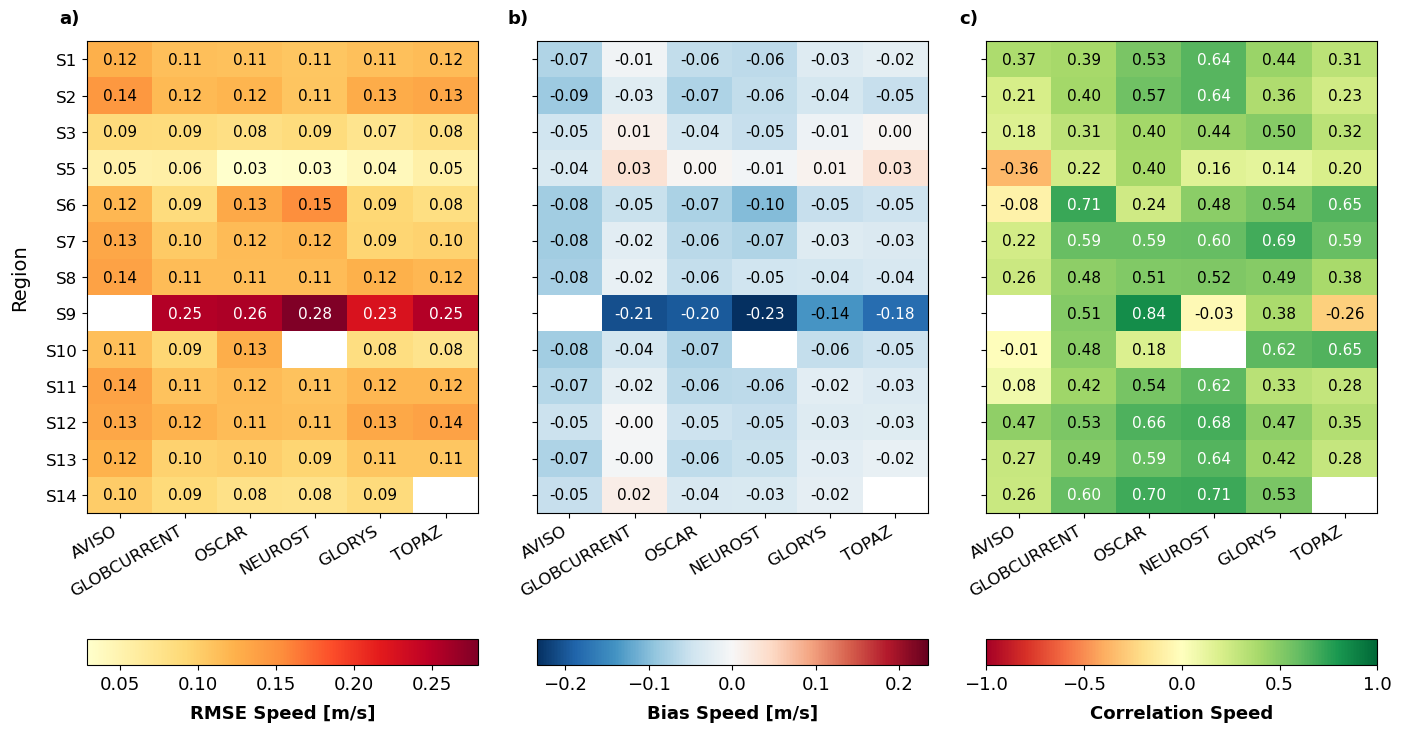

In [33]:
plot_regional_heatmap_new(
    regional_stats,
    metrics=['RMSE_Speed', 'Bias_Speed', 'Corr_Speed'],
    titles=['RMSE Speed [m/s]', 'Bias Speed [m/s]', 'Correlation Speed'],
    output_path=os.path.join(OUTPUT_DIR, 'regional_speed_heatmap.png')
)

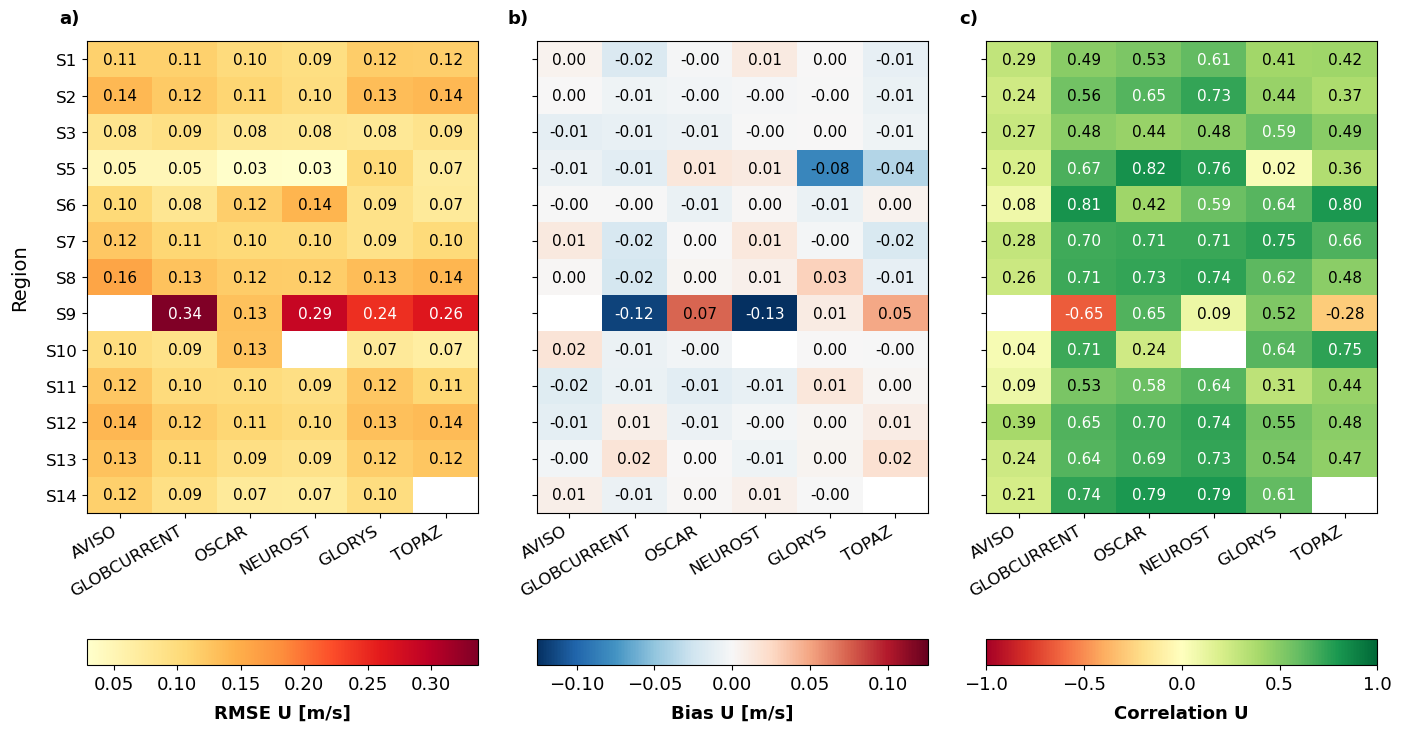

In [34]:
plot_regional_heatmap_new(
    regional_stats,
    metrics=['RMSE_U', 'Bias_U', 'Corr_U'],
    titles=['RMSE U [m/s]', 'Bias U [m/s]', 'Correlation U'],
    output_path=os.path.join(OUTPUT_DIR, 'regional_u_heatmap.png')
)

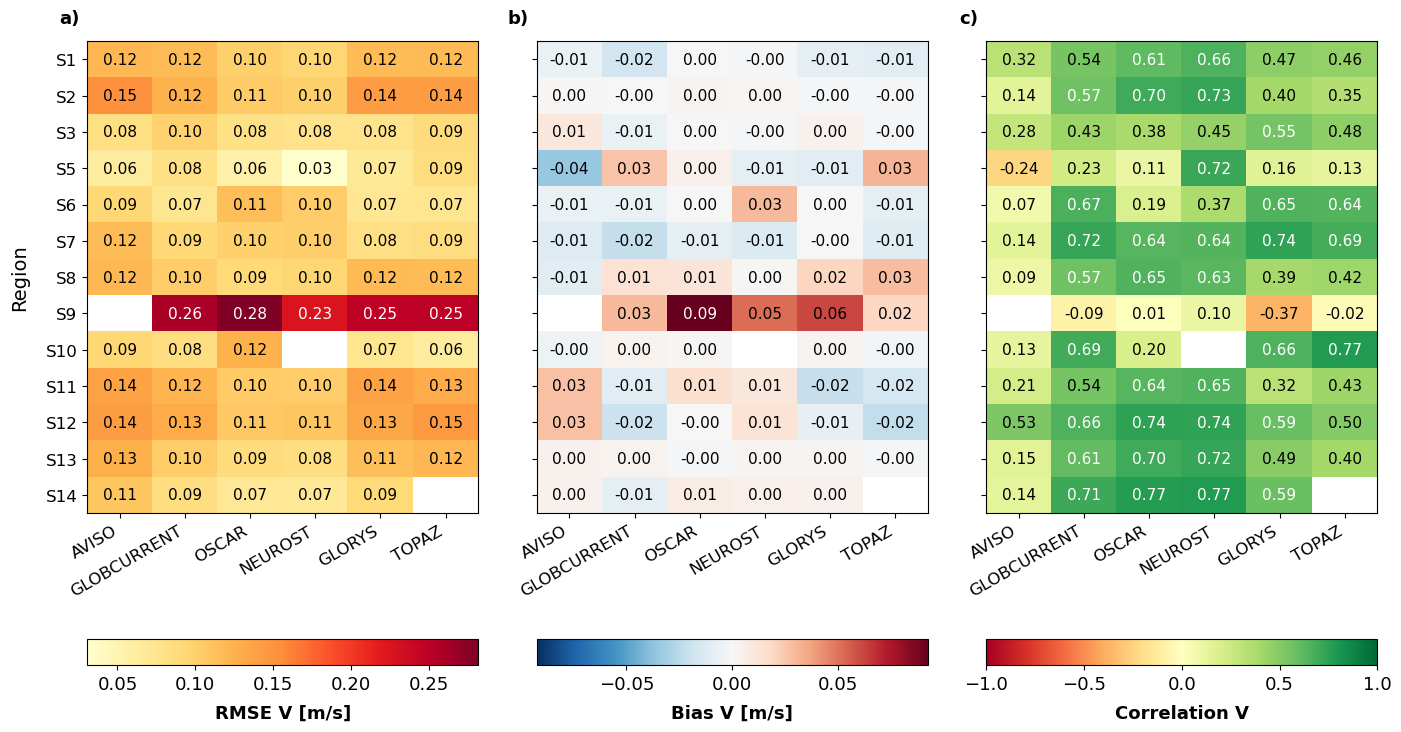

In [35]:
plot_regional_heatmap_new(
    regional_stats,
    metrics=['RMSE_V', 'Bias_V', 'Corr_V'],
    titles=['RMSE V [m/s]', 'Bias V [m/s]', 'Correlation V'],
    output_path=os.path.join(OUTPUT_DIR, 'regional_v_heatmap.png')
)

Generating Tight Centered Multi-Model Spaghetti Matrix...
Balanced grid figure with centered bottom plot saved at: /Users/jcreest/Documents/FRESH-CARE/WP1/outputs/multi_model_spaghetti_error03.png


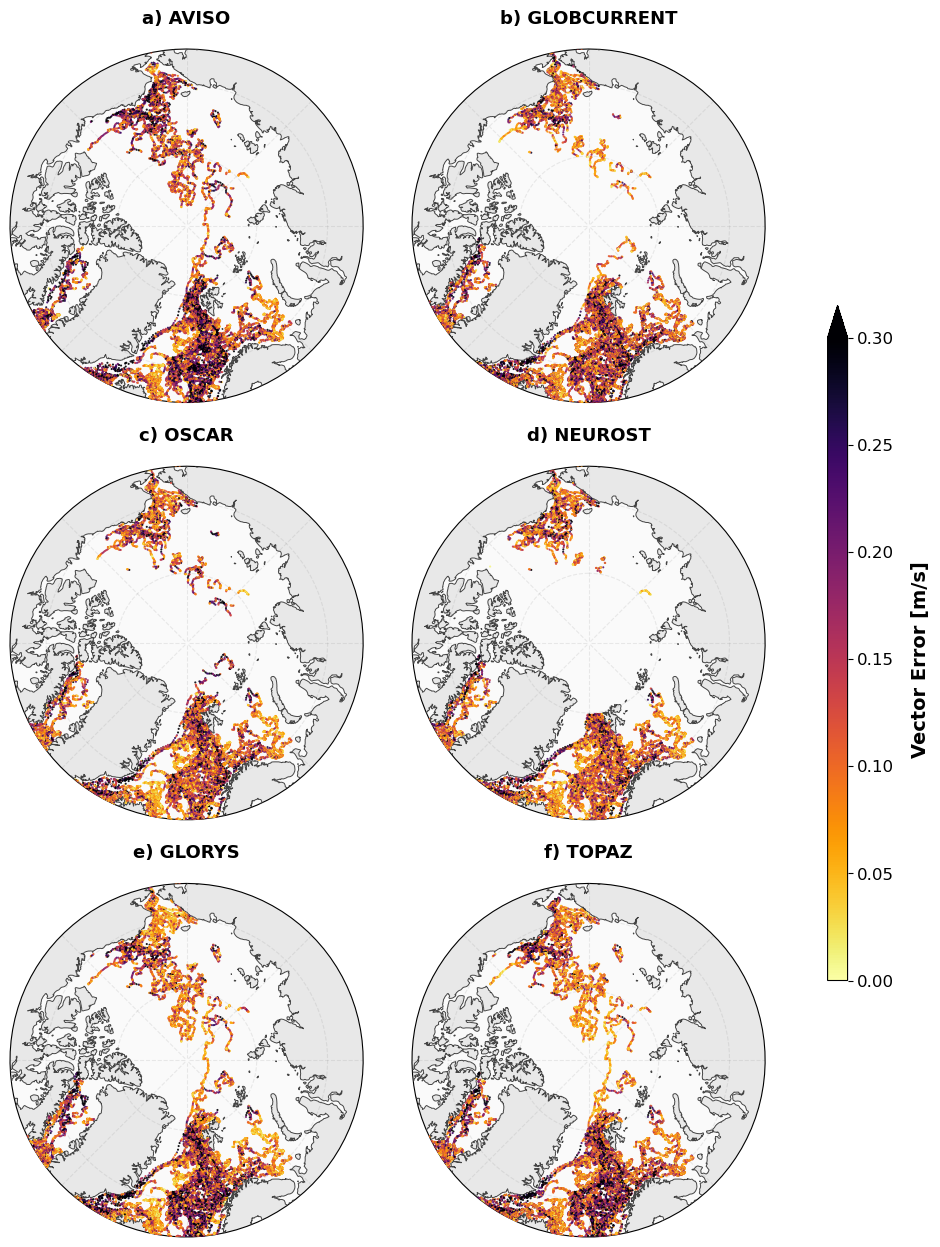

In [36]:
def plot_multi_model_spaghetti_matrix(df, save_name="multi_model_spaghetti_paper.png"):
    import matplotlib.cm as cm
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.path as mpath
    import numpy as np
    import os
    import matplotlib.pyplot as plt

    models = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']
    
    lat_col = 'latitude' if 'latitude' in df.columns else 'lat'
    lon_col = 'longitude' if 'longitude' in df.columns else ('lon360' if 'lon360' in df.columns else 'lon')

    projection_canvas = ccrs.NorthPolarStereo(central_longitude=0.0)
    fig = plt.figure(figsize=(10, 13.5))
    
    gs = fig.add_gridspec(3, 4, hspace=0.18, wspace=0.02)
    
    plot_positions = [
        gs[0, 0:2], gs[0, 2:4], 
        gs[1, 0:2], gs[1, 2:4],  
        gs[2, 0:2], gs[2,2:4]    
    ]

    error_cmap = cm.inferno_r
    norm_err = plt.Normalize(vmin=0, vmax=0.3)

    # Circular boundary path helper
    theta = np.linspace(0, 2 * np.pi, 100)
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)

    print("Generating Tight Centered Multi-Model Spaghetti Matrix...")

    for idx, model_name in enumerate(models):
        ax = fig.add_subplot(plot_positions[idx], projection=projection_canvas)
        
        # Filter and clean data
        subset = df[df['model_name'] == model_name].copy()
        subset = subset.dropna(subset=[lon_col, lat_col, 'u_obs', 'v_obs', 'u_model', 'v_model'])
        
        # Set map extent and circular clipping
        ax.set_extent([-180, 180, 65, 90], ccrs.PlateCarree())
        ax.set_boundary(circle, transform=ax.transAxes)
        
        # Background geography features
        ax.add_feature(cfeature.OCEAN, facecolor='#fafafa', zorder=1)
        ax.add_feature(cfeature.LAND, facecolor='#e8e8e8', edgecolor='none', zorder=2)
        ax.coastlines(resolution='50m', color='#444444', linewidth=0.7, zorder=3)
        
        # Gridlines grisos subtils
        gl = ax.gridlines(draw_labels=False, color='gray', alpha=0.15, linestyle="--", zorder=5)
        gl.ylocator = plt.FixedLocator([70, 80])       
        gl.xlocator = plt.FixedLocator(range(-180, 180, 45)) 


        if subset.empty:
            ax.text(0.5, 0.5, f"No data for {model_name}", transform=ax.transAxes, ha='center', va='center', fontsize=14)
            continue

        # Calculate metrics
        subset['vector_error'] = np.sqrt((subset['u_model'] - subset['u_obs'])**2 + (subset['v_model'] - subset['v_obs'])**2)
        
        lon_vals = subset[lon_col].values
        if lon_vals.max() > 180:
            lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
        lat_vals = subset[lat_col].values

        # Fast Vectorised Scatter Spaghetti
        sc = ax.scatter(
            lon_vals, lat_vals, 
            c=subset['vector_error'].values, 
            cmap=error_cmap, 
            norm=norm_err,
            s=2.3,  
            alpha=0.9, 
            edgecolors='none', 
            transform=ccrs.PlateCarree(), 
            zorder=4
        )
        
        ax.text(0.5, 1.06, f"{chr(97+idx)}) {model_name}", transform=ax.transAxes, 
                fontsize=13, fontweight='bold', va='bottom', ha='center')

    fig.subplots_adjust(left=0.06, right=0.86, top=0.94, bottom=0.06)

    # --- UNIFIED VERTICAL COLORBAR ON THE RIGHT ---
    cbar_ax = fig.add_axes([0.90, 0.25, 0.02, 0.5]) 
    sm = cm.ScalarMappable(cmap=error_cmap, norm=norm_err)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', extend='max')
    cbar.set_label("Vector Error [m/s]", fontsize=14, fontweight='bold', labelpad=12)
    cbar.ax.tick_params(labelsize=12)

    # Save and Show
    full_output_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(full_output_path, dpi=300, bbox_inches='tight')
    print(f"Balanced grid figure with centered bottom plot saved at: {full_output_path}")
    plt.show()

plot_multi_model_spaghetti_matrix(master_df, save_name="multi_model_spaghetti_error03.png")

Generating Tight Centered Multi-Model Bias Spaghetti Matrix...
Balanced bias grid figure saved at: /Users/jcreest/Documents/FRESH-CARE/WP1/outputs/multi_model_spaghetti_bias_speed_015.png


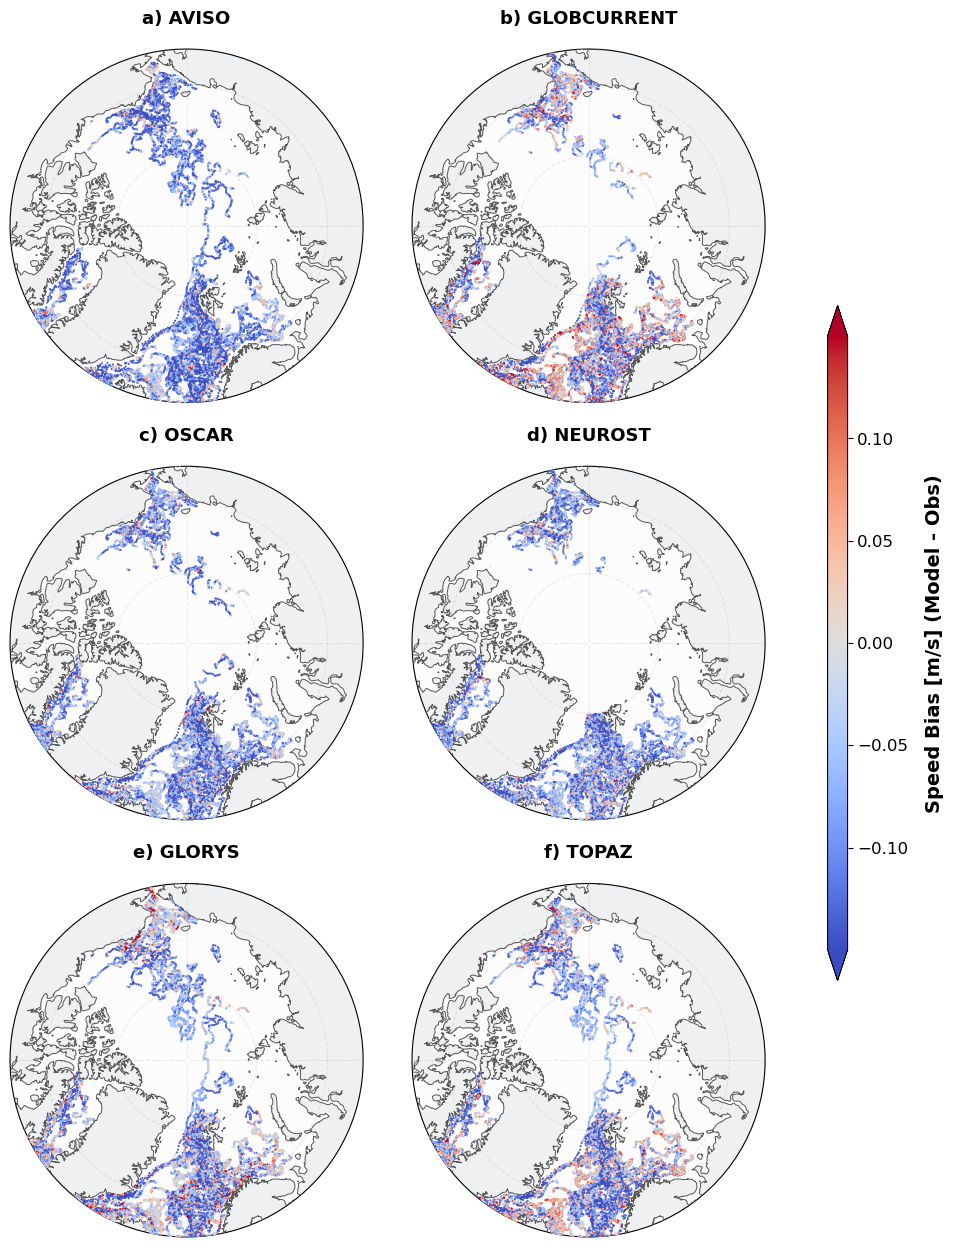

In [37]:
def plot_multi_model_spaghetti_bias(df, save_name="multi_model_spaghetti_bias_paper.png"):

    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.path as mpath
    import numpy as np
    import os
    import matplotlib.pyplot as plt

    models = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']
    
    lat_col = 'latitude' if 'latitude' in df.columns else 'lat'
    lon_col = 'longitude' if 'longitude' in df.columns else ('lon360' if 'lon360' in df.columns else 'lon')

    projection_canvas = ccrs.NorthPolarStereo(central_longitude=0.0)
    fig = plt.figure(figsize=(10, 13.5))
    
    gs = fig.add_gridspec(3, 4, hspace=0.18, wspace=0.02)
    
    plot_positions = [
        gs[0, 0:2], gs[0, 2:4],  
        gs[1, 0:2], gs[1, 2:4],  
        gs[2, 0:2], gs[2, 2:4]
    ]

    bias_cmap = cm.coolwarm
    norm_bias = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.15, vmax=0.15)

    # Circular boundary path helper
    theta = np.linspace(0, 2 * np.pi, 100)
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)

    print("Generating Tight Centered Multi-Model Bias Spaghetti Matrix...")

    for idx, model_name in enumerate(models):
        ax = fig.add_subplot(plot_positions[idx], projection=projection_canvas)
        
        # Filter and clean data
        subset = df[df['model_name'] == model_name].copy()
        subset = subset.dropna(subset=[lon_col, lat_col, 'speed_obs', 'speed_model'])
        
        # Set map extent and circular clipping
        ax.set_extent([-180, 180, 65, 90], ccrs.PlateCarree())
        ax.set_boundary(circle, transform=ax.transAxes)
        
        # Background geography features
        ax.add_feature(cfeature.OCEAN, facecolor='#fcfcfc', zorder=1)
        ax.add_feature(cfeature.LAND, facecolor='#eef0f2', edgecolor='none', zorder=2)
        ax.coastlines(resolution='50m', color='#555555', linewidth=0.7, zorder=3)
        
        # Gridlines
        gl = ax.gridlines(draw_labels=False, color='gray', alpha=0.15, linestyle="--", zorder=5)
        gl.ylocator = plt.FixedLocator([70, 80])       
        gl.xlocator = plt.FixedLocator(range(-180, 180, 90)) 
    

        if subset.empty:
            ax.text(0.5, 0.5, f"No data for {model_name}", transform=ax.transAxes, ha='center', va='center', fontsize=14)
            continue

        # --- bias computation
        subset['bias_speed'] = subset['speed_model'] - subset['speed_obs']
        
        lon_vals = subset[lon_col].values
        if lon_vals.max() > 180:
            lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)
        lat_vals = subset[lat_col].values
        

        # Fast Vectorised Scatter Spaghetti for Bias
        sc = ax.scatter(
            lon_vals, lat_vals, 
            c=subset['bias_speed'].values, 
            cmap=bias_cmap, 
            norm=norm_bias,
            s=2.3,  
            alpha=0.9, 
            edgecolors='none', 
            transform=ccrs.PlateCarree(), 
            zorder=4
        )
        
        ax.text(0.5, 1.06, f"{chr(97+idx)}) {model_name}", transform=ax.transAxes, 
                fontsize=13, fontweight='bold', va='bottom', ha='center')

    fig.subplots_adjust(left=0.06, right=0.86, top=0.94, bottom=0.06)

    # --- UNIFIED VERTICAL COLORBAR ON THE RIGHT ---
    cbar_ax = fig.add_axes([0.90, 0.25, 0.02, 0.5]) 
    sm = cm.ScalarMappable(cmap=bias_cmap, norm=norm_bias)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', extend='both')
    cbar.set_label("Speed Bias [m/s] (Model - Obs)", fontsize=14, fontweight='bold', labelpad=12)
    cbar.ax.tick_params(labelsize=12)

    # Save and Show
    full_output_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(full_output_path, dpi=300, bbox_inches='tight')
    print(f"Balanced bias grid figure saved at: {full_output_path}")
    plt.show()

plot_multi_model_spaghetti_bias(master_df, save_name="multi_model_spaghetti_bias_speed_015.png")

In [38]:
# Pre-compute spatial metrics binned on a 2° grid for all models
def compute_spatial_metrics(df, grid_res=2.0):
    """
    Returns a DataFrame with bias, rmse and corr
    for speed, u and v — per (model, grid cell).
    """
    lon_bins    = np.arange(-180, 180 + grid_res, grid_res)
    lat_bins    = np.arange(50,   90  + grid_res, grid_res)
    lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

    variables = {
        'speed': ('err_speed', 'speed_obs', 'speed_model'),
        'u':     ('err_u',     'u_obs',     'u_model'),
        'v':     ('err_v',     'v_obs',     'v_model'),
    }

    records = []
    for model in df['model_name'].unique():
        sub = df[df['model_name'] == model].dropna(
            subset=['latitude', 'longitude', 'err_speed', 'err_u', 'err_v']
        ).copy()
        sub['lon_bin'] = np.searchsorted(lon_bins, sub['longitude'], side='right') - 1
        sub['lat_bin'] = np.searchsorted(lat_bins, sub['latitude'],  side='right') - 1

        # Bias and RMSE via binned_statistic_2d
        grids = {}
        for var, (err_col, obs_col, mod_col) in variables.items():
            bias_g, _, _, _ = binned_statistic_2d(
                sub['longitude'], sub['latitude'], sub[err_col],
                statistic='mean', bins=[lon_bins, lat_bins]
            )
            rmse_g, _, _, _ = binned_statistic_2d(
                sub['longitude'], sub['latitude'], sub[err_col],
                statistic=lambda x: np.sqrt(np.mean(x**2)),
                bins=[lon_bins, lat_bins]
            )
            corr_g = np.full((len(lon_centers), len(lat_centers)), np.nan)
            for (li, lj), g in sub.groupby(['lon_bin', 'lat_bin'], observed=True):
                if 0 <= li < len(lon_centers) and 0 <= lj < len(lat_centers) and len(g) >= 3:
                    corr_g[li, lj] = g[obs_col].corr(g[mod_col])
            grids[var] = (bias_g, rmse_g, corr_g)

        for i, lon_c in enumerate(lon_centers):
            for j, lat_c in enumerate(lat_centers):
                row = {'model_name': model, 'lon_center': lon_c, 'lat_center': lat_c}
                for var, (bias_g, rmse_g, corr_g) in grids.items():
                    row[f'bias_{var}'] = bias_g[i, j]
                    row[f'rmse_{var}'] = rmse_g[i, j]
                    row[f'corr_{var}'] = corr_g[i, j]
                # Only keep cells that have at least one non-NaN value
                if any(not np.isnan(v) for k, v in row.items() if k != 'model_name'):
                    records.append(row)

    return pd.DataFrame(records)

spatial_metrics = compute_spatial_metrics(master_df)
print(spatial_metrics.columns.tolist())
print(spatial_metrics.shape)

['model_name', 'lon_center', 'lat_center', 'bias_speed', 'rmse_speed', 'corr_speed', 'bias_u', 'rmse_u', 'corr_u', 'bias_v', 'rmse_v', 'corr_v']
(21600, 12)


In [39]:
def plot_spatial_arctic_error_refined(spatial_df, model_name, metric='bias_speed', output_path=None):
    """
    Plots Arctic spatial metrics from spatial_metrics.
    metric examples: 'bias_speed', 'rmse_speed', 'corr_speed',
                     'bias_u', 'rmse_u', 'corr_u',
                     'bias_v', 'rmse_v', 'corr_v'
    """
    subset = spatial_df[
        (spatial_df['model_name'] == model_name) &
        spatial_df[metric].notna()
    ]

    if 'bias' in metric:
        cmap  = 'RdBu_r'
        limit = subset[metric].abs().max()
        norm  = TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit)
        label = f'Bias {metric.split("_")[1].upper()} — {model_name} [m/s]'
    elif 'corr' in metric:
        cmap  = 'RdYlGn'
        norm  = TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)
        label = f'Correlation {metric.split("_")[1].upper()} — {model_name}'
    else:
        cmap = 'YlOrRd'
        rmse_max = spatial_df[metric].max(skipna=True)
        vmax = rmse_max if pd.notna(rmse_max) and rmse_max > 0 else 1.0
        norm = plt.Normalize(vmin=0, vmax=vmax)
        label = f'RMSE {metric.split("_")[1].upper()} — {model_name} [m/s]'

    # Figure setup
    fig = plt.figure(figsize=(10, 10))
    ax  = plt.axes(projection=ccrs.NorthPolarStereo())
    ax.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())

    theta  = np.linspace(0, 2 * np.pi, 100)
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)

    sc = ax.scatter(
        subset['lon_center'], subset['lat_center'],
        c=subset[metric], cmap=cmap, norm=norm,
        s=60, transform=ccrs.PlateCarree(),
        zorder=1, edgecolors='none', alpha=0.85
    )

    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=10)
    ax.coastlines(resolution='50m', color='black', linewidth=0.7, zorder=11)
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.3, zorder=20)
    gl.top_labels   = False
    gl.right_labels = False

    cbar = plt.colorbar(sc, ax=ax, orientation='vertical',
                        pad=0.05, fraction=0.035, shrink=0.7)
    cbar.set_label(label, fontsize=12)

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

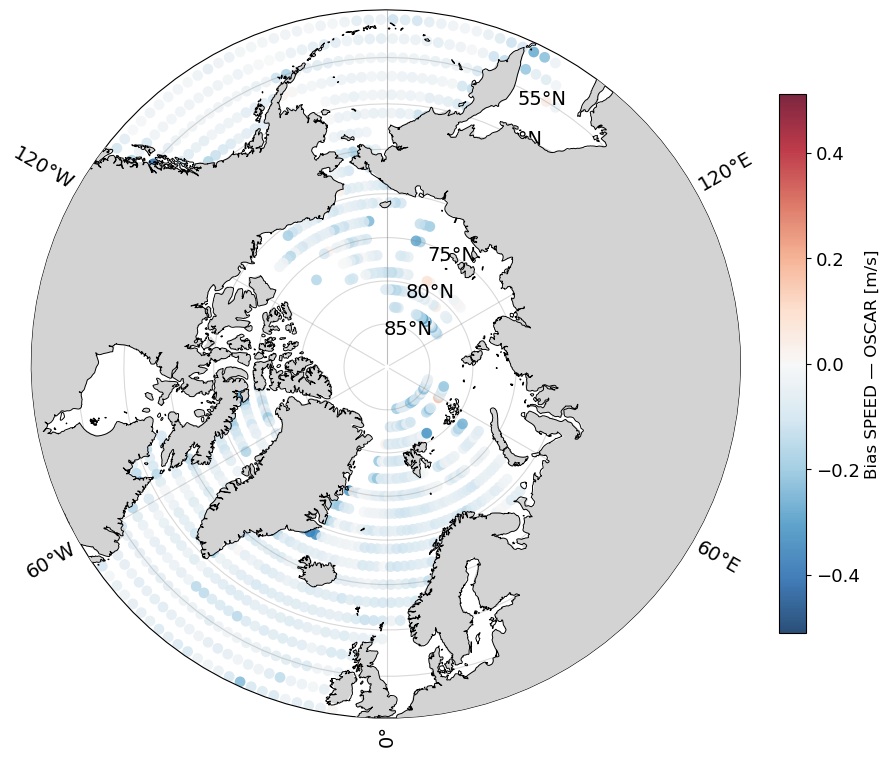

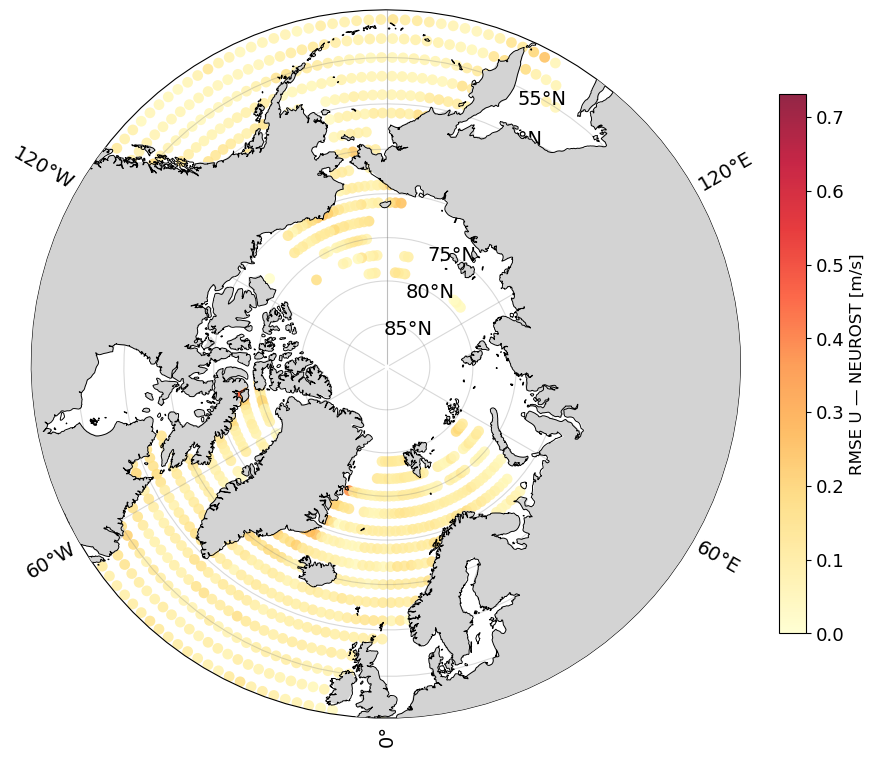

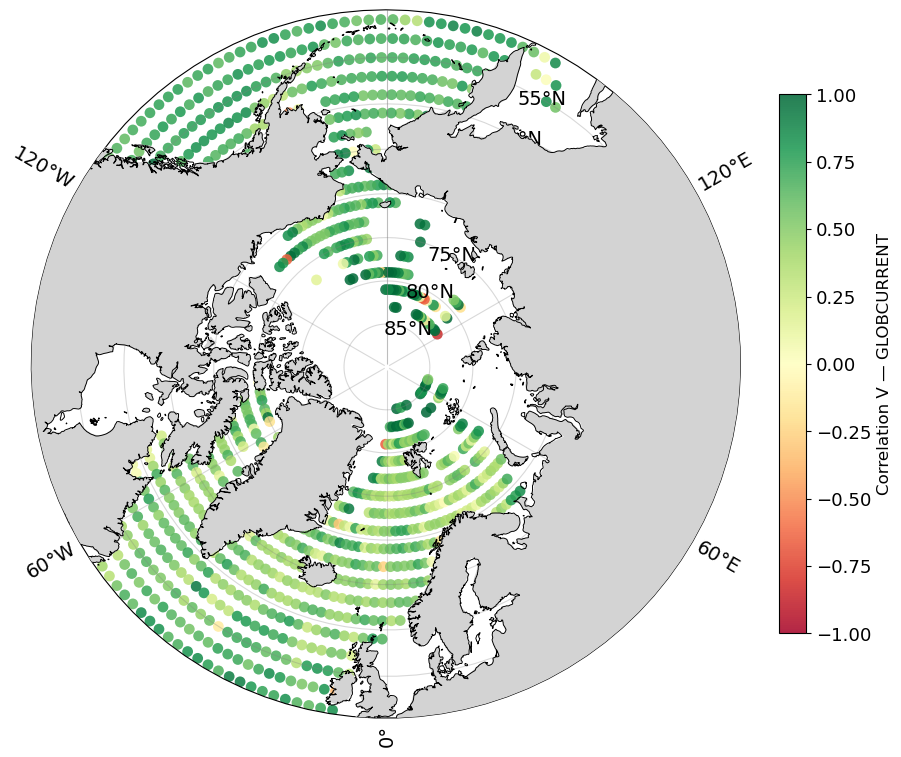

In [42]:
# Examples
plot_spatial_arctic_error_refined(spatial_metrics, 'OSCAR', metric='bias_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_bias_speed_oscar.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'NEUROST', metric='rmse_u',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_u_neurost.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'GLOBCURRENT', metric='corr_v',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_corr_v_globcurrent.png'))

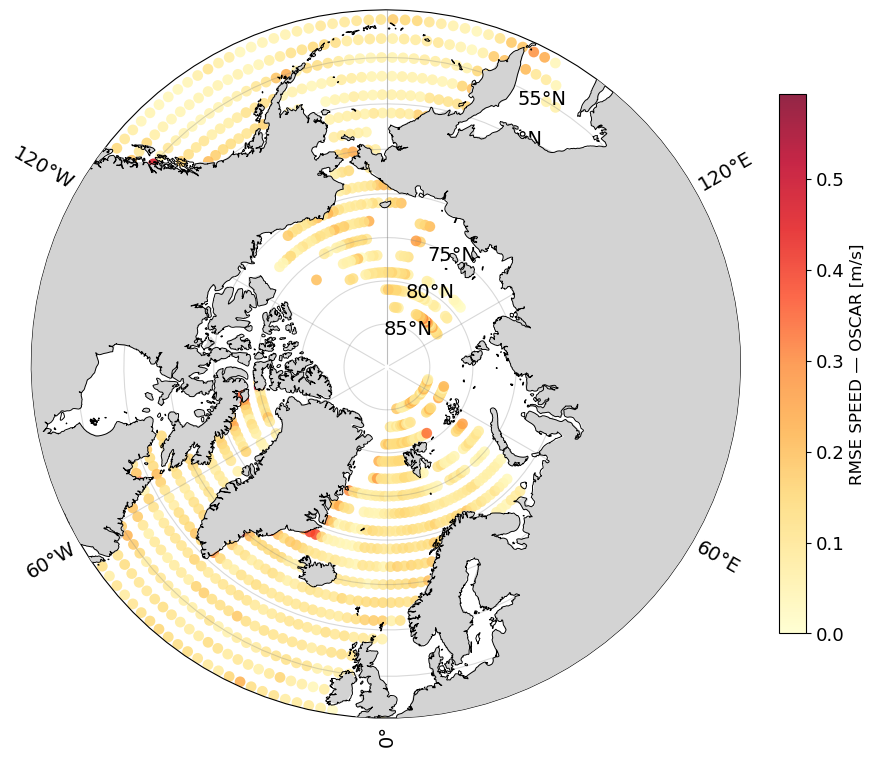

In [ ]:
# Examples
plot_spatial_arctic_error_refined(spatial_metrics, 'OSCAR', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_oscar.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'GLORYS', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_glorys.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'GLOBCURRENT', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_globcurrent.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'NEUROST', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_neurost.png'))

plot_spatial_arctic_error_refined(spatial_metrics, 'AVISO', metric='rmse_speed',
                                  output_path=os.path.join(OUTPUT_DIR, 'spatial_rmse_speed_aviso.png'))